<div style="background-color: #f4f6f7; padding: 20px; border-radius: 15px; border-left: 8px solid #2c3e50; text-align: center; box-shadow: 2px 2px 5px rgba(0,0,0,0.1);">
    <h1 style="font-family: 'Tahoma', sans-serif; color: #2c3e50; font-size: 42px; margin-bottom: 5px;">دینامیک تکاملی</h1>
    <h2 style="font-family: 'Georgia', serif; color: #7f8c8d; font-size: 28px; font-style: italic; margin-top: 0;">Evolutionary Dynamics</h2>
</div>

# مقدمه‌ای بر دینامیک تکاملی و مدل‌سازی ریاضی
### (Evolutionary Dynamics & Game Theory)

این نوت‌بوک به بررسی مفاهیم ریاضی تکامل، نظریه بازی‌های تکاملی و پیاده‌سازی آن‌ها در پایتون می‌پردازد. در اینجا خلاصه‌ای از مبانی نظری و روش‌های محاسباتی ارائه شده است.

---

## ۱. ارکان اصلی دینامیک تکاملی
دینامیک تکاملی تغییرات جمعیت‌ها را در طول زمان بر اساس سه اصل کلیدی مدل‌سازی می‌کند:
1.  **تکثیر (Replication):** توانایی اعضای جمعیت برای تولید مثل.
2.  **جهش (Mutation):** اشتباهات تصادفی در کپی‌برداری که منجر به تنوع می‌شود.
3.  **انتخاب (Selection):** بقای افرادی که استراتژی (ژن) آن‌ها با محیط سازگارتر است.

---

## ۲. معادله رپلیکیتور (Replicator Equation)
این معادله نشان می‌دهد که فراوانی یک استراتژی ($x_i$) چگونه بر اساس موفقیتش نسبت به جامعه تغییر می‌کند:

$$\dot{x}_i = x_i (f_i - \phi)$$

* $x_i$: نسبت جمعیت دارای استراتژی $i$.
* $f_i$: برازش یا شایستگی (Fitness) استراتژی $i$.
* $\phi$: میانگین شایستگی کل جمعیت.
* **تفسیر:** اگر شایستگی یک گونه ($f_i$) از میانگین جامعه ($\phi$) بیشتر باشد، جمعیت آن رشد می‌کند ($\dot{x} > 0$).

---

## ۳. محاسبات ماتریسی در جمعیت
در بازی‌های تکاملی، موفقیت یک فرد وابسته به تعامل با **توزیع کل جمعیت** است. اگر $A$ ماتریس پاداش و $y$ بردار جمعیت باشد:

$$f_i = (A_{\text{row } i}) \cdot y$$

این یعنی برای محاسبه امتیاز استراتژی $i$، ردیف مربوط به آن در ماتریس پاداش، در بردار ستونی جمعیت **ضرب داخلی** می‌شود. این مدل ریاضی نشان‌دهنده **انتخاب وابسته به فراوانی** (Frequency Dependent Selection) است.

---

## ۴. معادله لجستیک (Logistic Growth)
در حالی که معادله رپلیکیتور رقابت بین استراتژی‌هاست، معادله لجستیک رشد جمعیت با **محدودیت منابع** را نشان می‌دهد:

$$\frac{dN}{dt} = rN \left( 1 - \frac{N}{K} \right)$$

* $r$: نرخ رشد ذاتی.
* $K$: **ظرفیت برد (Carrying Capacity)** یا سقف محیط.
* این معادله ترمزی برای رشد نمایی است و جمعیت را در حد $K$ پایدار می‌کند.

---

## ۵. ابزارهای پیاده‌سازی در پایتون
برای شبیه‌سازی این مفاهیم از کتابخانه‌های زیر استفاده می‌شود:
* **`Nashpy`**: ابزار اختصاصی برای نظریه بازی‌ها و حل معادله رپلیکیتور (مثلاً برای بازی سنگ-کاغذ-قیچی).
* **`SciPy (odeint)`**: حل‌گر عمومی معادلات دیفرانسیل برای مدل‌های پیچیده و سفارشی (مانند مدل لجستیک).
* **`NumPy`**: برای انجام عملیات جبر خطی و ضرب ماتریس‌ها.

# کتابخانه Nashpy: ابزار تحلیل بازی‌ها در پایتون

کتابخانه **Nashpy** یک پکیج قدرتمند و سبک در پایتون است که برای حل بازی‌های **۲ نفره** (2-Player Games) در فرم نرمال (استراتژیک) طراحی شده است. این ابزار پلی میان مفاهیم ریاضی نظریه بازی‌ها و پیاده‌سازی محاسباتی است.

---

## ۱. ساختار اصلی: کلاس `Game`
هسته اصلی این کتابخانه کلاس `nash.Game` است. برای تعریف یک بازی، ما نیاز به ماتریس‌های پاداش (Payoff Matrices) داریم:

* **بازی‌های مجموع-صفر (Zero-Sum):** فقط یک ماتریس $A$ داده می‌شود. سود بازیکن اول، ضرر بازیکن دوم است ($A = -B$).
* **بازی‌های عمومی (General-Sum):** دو ماتریس $A$ و $B$ داده می‌شود. $A$ پاداش بازیکن اول (ردیف) و $B$ پاداش بازیکن دوم (ستون) است.

```python
import nashpy as nash
# ساخت بازی با دو ماتریس پاداش
game = nash.Game(A, B)

Rock-Paper-Scissors in nashpy

در این بخش، ما یک مدل تکاملی را برای بازی معروف سنگ، کاغذ و قیچی پیاده‌سازی می‌کنیم. هدف اصلی این است که ببینیم اگر سه جمعیت با استراتژی‌های متفاوت با هم رقابت کنند، در طول زمان چه اتفاقی برای جمعیت آن‌ها می‌افتد. بر اساس قوانین انتخاب طبیعی، هر گروهی که عملکرد بهتری داشته باشد، رشد می‌کند. در این شبیه‌سازی مشاهده خواهیم کرد که به جای اینکه یک گروه برنده نهایی شود، یک الگوی چرخشی و نوسانی بین جمعیت‌ها شکل می‌گیرد زیرا هر گروه توسط گروهی دیگر شکست می‌خورد و تعادل پویایی ایجاد می‌شود.


 








 ### Rock-Paper-Scissors Evolutionary Dynamics

**1. Replicator Dynamics Equation:**
The evolution of strategies is governed by the Replicator Equation:
$$\dot{x}_i = x_i (f_i(x) - \phi(x))$$

Where:
* $x_i$: Frequency of strategy $i$
* $f_i(x)$: Fitness of strategy $i$ given the current population state
* $\phi(x)$: Average fitness of the population ($\sum x_j f_j(x)$)

**2. Payoff Matrix ($A$):**
For the Rock-Paper-Scissors game, the payoff matrix is defined as a zero-sum game:
$$A = \begin{pmatrix} 0 & -1 & 1 \\ 1 & 0 & -1 \\ -1 & 1 & 0 \end{pmatrix}$$
* Rows/Cols: 1=Rock, 2=Paper, 3=Scissors

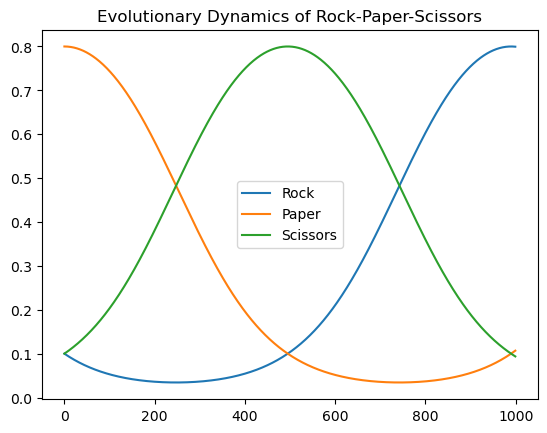

In [1]:
import nashpy as nash
import numpy as np
import matplotlib.pyplot as plt

# 1. تعریف ماتریس پاداش (سنگ، کاغذ، قیچی)
# A ماتریس نفر اول است
A = np.array([
    [0, -1, 1],  # سنگ
    [1, 0, -1],  # کاغذ
    [-1, 1, 0]   # قیچی
])

# 2. ساخت بازی
game = nash.Game(A)

# 3. شبیه‌سازی دینامیک تکاملی (Replicator Dynamics)
# y0: وضعیت اولیه جمعیت (مثلاً 10% سنگ، 80% کاغذ، 10% قیچی)
y0 = np.array([0.1, 0.8, 0.1])
timepoints = np.linspace(0, 10, 1000)

# محاسبه مسیر تکامل
history = game.replicator_dynamics(y0=y0, timepoints=timepoints)

# 4. رسم نمودار
plt.plot(history)
plt.legend(['Rock', 'Paper', 'Scissors'])
plt.title('Evolutionary Dynamics of Rock-Paper-Scissors')
plt.show()

در این بخش، مدل رشد لجستیک را شبیه‌سازی می‌کنیم. این مدل یکی از واقع‌گرایانه‌ترین روش‌ها برای توصیف رشد جمعیت در طبیعت است. ایده اصلی این است 
که محیط دارای منابع محدودی (مانند غذا و فضا) است که به آن «ظرفیت برد» می‌گویند. در ابتدا که منابع زیاد است، جمعیت به سرعت رشد می‌کند، اما هرچه تعداد افراد بیشتر می‌شود و به سقف ظرفیت محیط نزدیک می‌شوند، رقابت افزایش یافته و سرعت رشد کاهش می‌یابد تا در نهایت جمعیت روی یک مقدار ثابت متوقف شود. جزئیات ریاضی و فرمول دیفرانسیل مربوط به این مدل در سلول بعدی نمایش داده شده است.













logistic


### Logistic Growth Model

**1. The Differential Equation:**
Population growth with limited resources is described by the Logistic Equation:
$$\frac{dN}{dt} = rN \left(1 - \frac{N}{K}\right)$$

**2. Parameters:**
* $N$: Current population size
* $t$: Time
* $r$: Intrinsic growth rate (Malthusian parameter)
* $K$: Carrying capacity (maximum population environment can sustain)

**3. Dynamics:**
* When $N \ll K$: Growth is approximately exponential ($\approx rN$).
* When $N \to K$: The term $(1 - N/K)$ approaches zero, and growth stops ($\frac{dN}{dt} = 0$).


















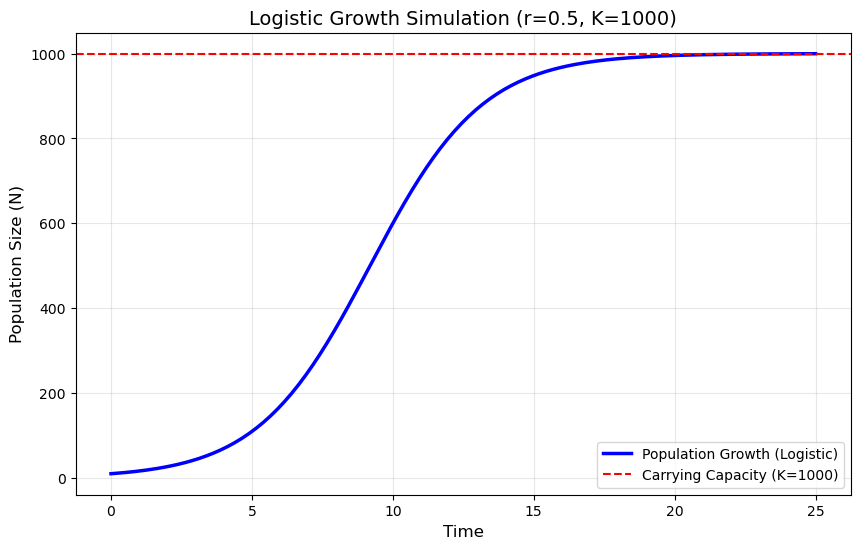

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. تعریف معادله دیفرانسیل لجستیک
def logistic_equation(N, t, r, K):
    """
    dN/dt = r * N * (1 - N/K)
    """
    dndt = r * N * (1 - N / K)
    return dndt

# 2. تنظیم پارامترهای شبیه‌سازی
N0 = 10         # جمعیت اولیه (Initial Population)
K = 1000        # ظرفیت برد محیط (Carrying Capacity)
r = 0.5         # نرخ رشد (Growth Rate)
t = np.linspace(0, 25, 200)  # بازه زمانی (از 0 تا 25 ثانیه)

# 3. حل معادله با استفاده از odeint
# ورودی‌ها: تابع مدل، شرایط اولیه، نقاط زمانی، و پارامترهای اضافی (r, K)
solution = odeint(logistic_equation, N0, t, args=(r, K))

# 4. رسم نمودار
plt.figure(figsize=(10, 6))

# رسم منحنی تغییرات جمعیت
plt.plot(t, solution, label='Population Growth (Logistic)', color='blue', linewidth=2.5)

# رسم خط ظرفیت برد (سقف محیط)
plt.axhline(y=K, color='red', linestyle='--', label=f'Carrying Capacity (K={K})')

# تنظیمات ظاهری نمودار
plt.title(f'Logistic Growth Simulation (r={r}, K={K})', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Population Size (N)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# نمایش نمودار
plt.show()

در این بخش، از روش مصورسازی نمودار مثلثی (که در ریاضیات به آن سیمپلکس می‌گویند) استفاده می‌کنیم. در نظریه بازی‌ها، زمانی که مجموع احتمالات چند  استراتژی (مانند سنگ، کاغذ و قیچی) همیشه باید برابر با ۱۰۰٪ باشد، نمی‌توانیم از نمودارهای معمولی استفاده کنیم. در عوض، از یک مثلث استفاده می‌کنیم که در آن هر گوشه نشان‌دهنده غلبه کامل یک استراتژی است و نقاط داخلی، ترکیبی از هر سه حالت را نشان می‌دهند. این روش به ما اجازه می‌دهد تغییرات جمعیت هر سه گونه را به صورت هم‌زمان در یک فضای واحد مشاهده کنیم. جزئیات ریاضی و نحوه محاسبه مختصات در این مثلث، در سلول بعدی آمده است.

symplex 




### Simplex Visualization (Ternary Plot)

**1. The Simplex Constraint ($S_3$):**
Since the population proportions represent probabilities, they must sum to unity. The state space is defined as the 2-simplex:
$$S_3 = \{ (x, y, z) \in \mathbb{R}^3 \mid x + y + z = 1, \quad x, y, z \ge 0 \}$$

**2. Barycentric Coordinates:**
Any point $P$ inside the triangle is defined by three coordinates $(x, y, z)$ representing the weight of each vertex (Strategy).
* **Vertices:** Pure strategies, e.g., Rock = $(1, 0, 0)$.
* **Center:** The Nash Equilibrium (Mixed Strategy) at $(\frac{1}{3}, \frac{1}{3}, \frac{1}{3})$.

**3. Trajectory Mapping:**
To plot a trajectory on the simplex, we map the 3D probability vector $\mathbf{x}(t)$ onto the 2D planar triangle using projection methods provided by the `python-ternary` library.

/Users/amirhosein/miniconda3/envs/comp-phy/lib/python3.11/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


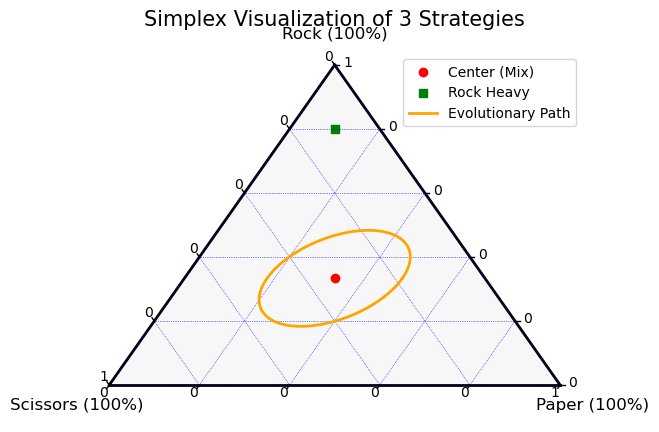

In [3]:


import ternary
import matplotlib.pyplot as plt
import numpy as np

# 1. تنظیمات اولیه نمودار
scale = 1.0  # مقیاس (مجموع احتمالات برابر 1)
figure, tax = ternary.figure(scale=scale)

# 2. رسم مرزها و شبکه
tax.boundary(linewidth=2.0)
tax.gridlines(multiple=0.2, color="blue")

# 3. نام‌گذاری رئوس (استراتژی‌ها)
fontsize = 12
tax.left_corner_label("Scissors (100%)", fontsize=fontsize)
tax.right_corner_label("Paper (100%)", fontsize=fontsize)
tax.top_corner_label("Rock (100%)", fontsize=fontsize)

# 4. نمایش نقاط خاص روی سیمپلکس
# پایتون-ترنری مختصات را به صورت (i, j, k) می‌گیرد که i=راست، j=بالا، k=چپ (معمولاً)
# اما ترتیب استاندارد معمولاً (Right, Top, Left) است.

# نقطه مرکزی (تعادل مخلوط)
p_center = (1/3, 1/3, 1/3)
tax.scatter([p_center], marker='o', color='red', label='Center (Mix)')

# نقطه نزدیک به سنگ
p_rock_heavy = (0.1, 0.8, 0.1) # توجه: ترتیب محورها بسته به تنظیمات ممکن است متفاوت باشد
tax.scatter([p_rock_heavy], marker='s', color='green', label='Rock Heavy')

# 5. رسم یک مسیر فرضی (Trajectory)
# فرض کنید جمعیت در حال تغییر است (یک مسیر دایره‌ای فرضی)
t = np.linspace(0, 2*np.pi, 100)
r = 0.15
# ساخت یک دایره دور مرکز
points = []
for val in t:
    x = 1/3 + r * np.cos(val)
    y = 1/3 + r * np.sin(val)
    z = 1 - x - y
    points.append((x, y, z))

tax.plot(points, linewidth=2.0, color='orange', label='Evolutionary Path')

# 6. نمایش نهایی
tax.legend()
tax.ticks(axis='lbr', linewidth=1, multiple=0.2)
tax.clear_matplotlib_ticks()
tax.get_axes().axis('off') # حذف محورهای مربعی استاندارد
plt.title("Simplex Visualization of 3 Strategies", fontsize=15, y=1.05)
plt.show()

در این بخش، ما وارد دنیای شگفت‌انگیز «نظریه آشوب» می‌شویم. برخلاف مدل‌های قبلی که زمان به صورت پیوسته و روان جلو می‌رفت (مثل جریان آب)، در اینجا زمان به صورت «پله‌پله» یا نسل‌به‌نسل جلو می‌رود (مثل درختان که هر سال یک بار شکوفه می‌دهند).

این مدل ریاضی که «نقشه لجستیک» نام دارد، نشان می‌دهد که چگونه یک قانون بسیار ساده می‌تواند منجر به رفتارهای بسیار پیچیده و غیرقابل پیش‌بینی شود. ما در این شبیه‌سازی یک پارامتر مهم به نام «نرخ رشد» داریم که مثل ولوم یک رادیو عمل می‌کند:
۱. اگر ولوم (نرخ رشد) کم باشد، جمعیت نمی‌تواند خود را حفظ کند و منقرض می‌شود.
۲. اگر ولوم را کمی زیاد کنیم، جمعیت رشد کرده و به یک ثبات پایدار می‌رسد.
۳. اما نکته جالب زمانی رخ می‌دهد که ولوم را خیلی زیاد کنیم؛ در این حالت جمعیت دیگر ثابت نمی‌شود، بلکه شروع به نوسان‌های شدید می‌کند و وارد حالتی می‌شود که به آن «آشوب» می‌گویند. در حالت آشوب، جمعیت هر سال عددی متفاوت است و هیچ الگوی تکراری منظمی ندارد، انگار که همه چیز تصادفی است، در حالی که همه چیز از یک فرمول ریاضی دقیق پیروی می‌کند. فرمول‌ها و بازه‌های ریاضی مربوط به این رفتارها در سلول بعدی نمایش داده شده است.

### Discrete Logistic Map (Bifurcation & Chaos)

**1. The Recurrence Relation:**
This model describes population growth in discrete time steps (generations):
$$x_{t+1} = a x_t (1 - x_t)$$

**2. Parameters:**
* $x_t$: Population density at generation $t$ ($0 \le x \le 1$)
* $a$: Growth rate parameter ($0 \le a \le 4$)

**3. [cite_start]Behavioral Regimes (Based on parameter $a$):** [cite: 8, 9, 10, 11]
* **Extinction ($0 < a < 1$):** Population converges to zero ($x^* = 0$).
* **Stability ($1 < a < 3$):** Population converges to a stable fixed point ($x^* = \frac{a-1}{a}$).
* **Period Doubling ($3 < a < 3.57$):** Population oscillates between 2, 4, 8... values.
* **Chaos ($a > 3.57$):** The system exhibits sensitive dependence on initial conditions (The Butterfly Effect).

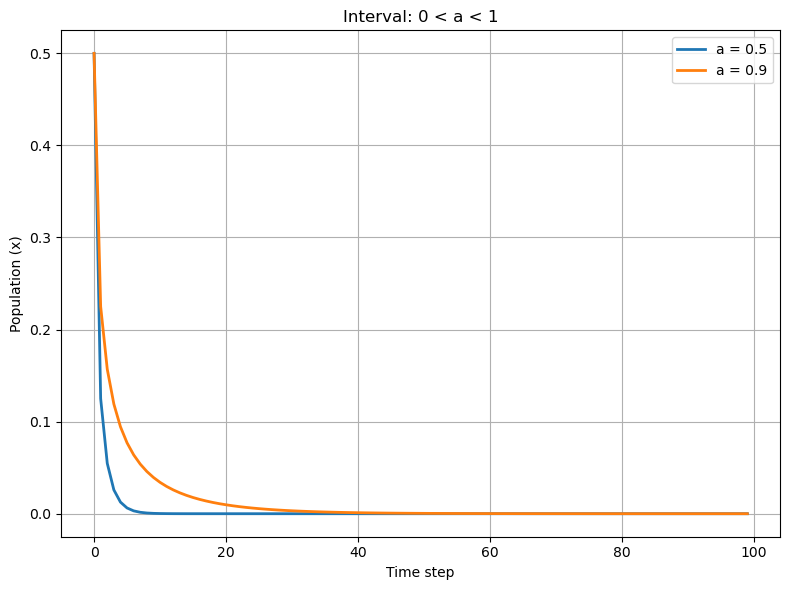

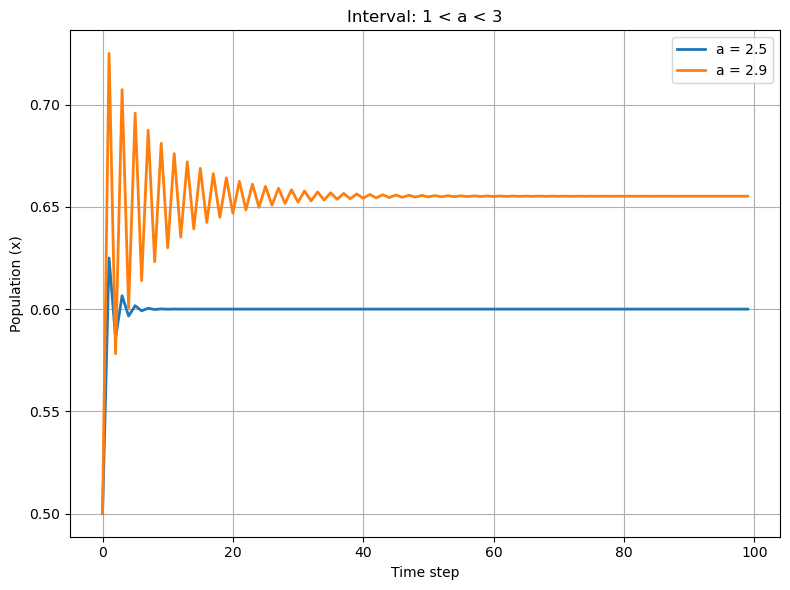

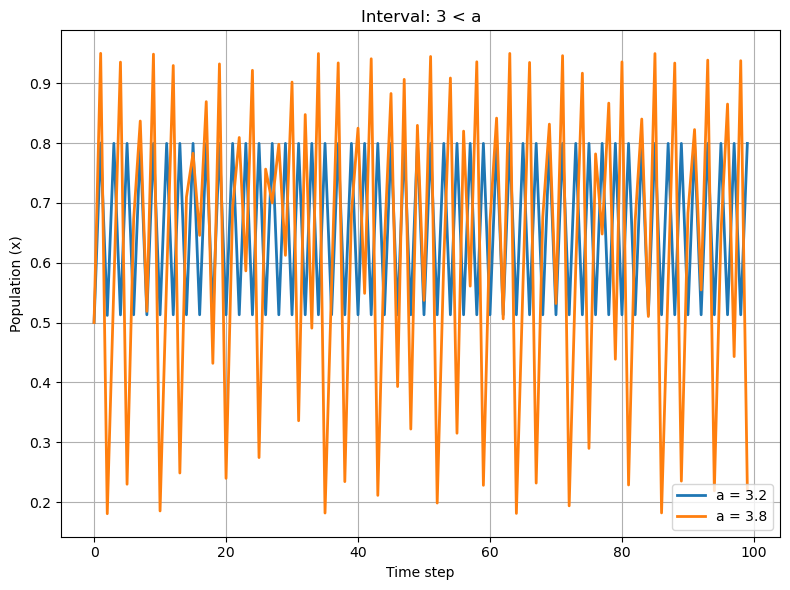

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. تعریف تابع نقشه لجستیک
def logistic_map(x, a):
    return a * x * (1 - x)

# 2. تنظیم پارامترها
# بازه‌های مختلف پارامتر a برای بررسی رفتارهای متفاوت (همگرایی، تناوب، آشوب)
a_intervals = [(0.5, 0.9), (2.5, 2.9), (3.2, 3.8)]
interval_labels = ["0 < a < 1", "1 < a < 3", "3 < a"]

time_steps = 100   # تعداد تکرارها (نسل‌ها)
x0 = 0.5           # جمعیت اولیه

# 3. حلقه برای محاسبه و رسم نمودارها
for i, (a1, a2) in enumerate(a_intervals):
    # ایجاد آرایه برای ذخیره مقادیر جمعیت در طول زمان
    x1 = np.zeros(time_steps)
    x2 = np.zeros(time_steps)
    
    # مقدار دهی اولیه
    x1[0] = x0
    x2[0] = x0
    
    # محاسبه نسل‌های بعدی
    for t in range(1, time_steps):
        x1[t] = logistic_map(x1[t-1], a1)
        x2[t] = logistic_map(x2[t-1], a2)
    
    # رسم نمودار
    plt.figure(figsize=(8, 6))
    plt.plot(range(time_steps), x1, label=f"a = {a1}", linewidth=2)
    plt.plot(range(time_steps), x2, label=f"a = {a2}", linewidth=2)
    
    plt.title(f"Interval: {interval_labels[i]}")
    plt.xlabel("Time step")
    plt.ylabel("Population (x)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

در این بخش، ما ساده‌ترین و شاید رویایی‌ترین حالت رشد جمعیت را بررسی می‌کنیم که به آن «رشد نمایی» می‌گویند. فرض کنید دو گونه جانوری متفاوت در محیطی زندگی می‌کنند که منابع (مثل آب، غذا و فضا) کاملاً نامحدود است و هیچ‌چیزی مانع رشد آن‌ها نمی‌شود. در چنین شرایط آرمانی، جمعیت با شتابی فزاینده و انفجاری زیاد می‌شود، دقیقاً مثل سودی که در بانک روی سود قبلی می‌آید.

ما در این شبیه‌سازی دو سناریوی موازی را مقایسه می‌کنیم:
۱. در حالت اول، گونه آبی‌رنگ نرخ زاد و ولد بیشتری نسبت به گونه قرمز دارد.
۲. در حالت دوم، جای آن‌ها عوض می‌شود.

شما روی نمودارها خواهید دید که هر دو جمعیت بدون توقف بالا می‌روند (شکل منحنی شبیه حرف J انگلیسی می‌شود)، اما نکته مهم اینجاست که نشان دهیم حتی یک تفاوت کوچک در «سرعت رشد»، چطور می‌تواند در درازمدت باعث شود جمعیت یک گونه، میلیون‌ها برابر گونه دیگر شود. فرمول‌های ریاضی این رشد انفجاری در سلول بعدی آمده است.

### Exponential Growth (Independent Populations)

**1. The Model:**
In the absence of environmental constraints (unlimited resources), populations grow exponentially according to Malthusian growth laws. The growth of each species is independent of the other:
$$\frac{dx_1}{dt} = a x_1$$
$$\frac{dx_2}{dt} = b x_2$$

**2. Analytical Solution:**
These linear differential equations have exact solutions:
$$x_1(t) = x_1(0) e^{at}$$
$$x_2(t) = x_2(0) e^{bt}$$

**3. Dynamics:**
* Since there is no interaction term (like competition $-\phi x$), both populations grow to infinity ($x \to \infty$ as $t \to \infty$).
* The species with the higher intrinsic growth rate ($a > b$ or $b > a$) will dominate in numbers, creating a steep J-curve trajectory.

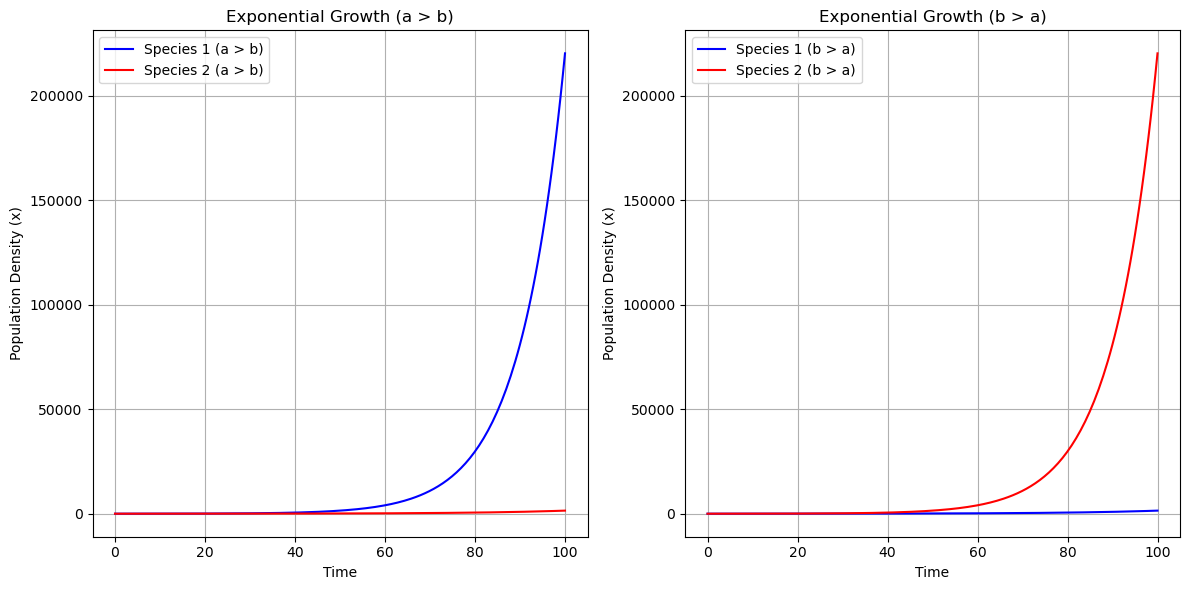

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. تعریف مدل معادلات دیفرانسیل
def model(x, t, a, b):
    x1, x2 = x
    # رشد هر گونه فقط به جمعیت خودش بستگی دارد (مستقل)
    dx1dt = a * x1
    dx2dt = b * x2
    return [dx1dt, dx2dt]

# 2. تنظیم پارامترهای شبیه‌سازی
# حالت اول: a > b (گونه اول سریع‌تر است)
a1 = 0.1
b1 = 0.05

# حالت دوم: b > a (گونه دوم سریع‌تر است)
a2 = 0.05
b2 = 0.1

# شرایط اولیه
x1_0 = 10   # جمعیت اولیه گونه 1
x2_0 = 10   # جمعیت اولیه گونه 2
x0 = [x1_0, x2_0]

# زمان
t = np.linspace(0, 100, 200)

# 3. حل معادلات
sol1 = odeint(model, x0, t, args=(a1, b1))
sol2 = odeint(model, x0, t, args=(a2, b2))

# 4. رسم نمودارها
plt.figure(figsize=(12, 6))

# نمودار حالت اول (a > b)
plt.subplot(1, 2, 1)
plt.plot(t, sol1[:, 0], label="Species 1 (a > b)", color='b')
plt.plot(t, sol1[:, 1], label="Species 2 (a > b)", color='r')
plt.title("Exponential Growth (a > b)")
plt.xlabel("Time")
plt.ylabel("Population Density (x)")
plt.legend()
plt.grid()

# نمودار حالت دوم (b > a)
plt.subplot(1, 2, 2)
plt.plot(t, sol2[:, 0], label="Species 1 (b > a)", color='b')
plt.plot(t, sol2[:, 1], label="Species 2 (b > a)", color='r')
plt.title("Exponential Growth (b > a)")
plt.xlabel("Time")
plt.ylabel("Population Density (x)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

در بخش قبلی دیدیم که اگر منابع نامحدود باشد، همه خوشحال و خندان رشد می‌کنند. اما در دنیای واقعی، منابع (غذا، انرژی، قلمرو) محدود است. این مدل، سناریویی را شبیه‌سازی می‌کند که در آن «جمعیت کل ثابت» است (مثلاً ۱۰۰٪ فضای یک جزیره پر شده است).

این یعنی یک بازی با حاصل‌جمع صفر: **رشد یک گونه فقط با کاهش گونه دیگر امکان‌پذیر است.**

در اینجا ما مفهوم «برازش» یا Fitness را معرفی می‌کنیم. هر گونه‌ای که کارایی یا برازش بالاتری داشته باشد (مثلاً بهتر شکار کند یا در برابر بیماری مقاوم‌تر باشد)، به مرور زمان سهم بیشتری از کیکِ ثابتِ جمعیت را از آن خود می‌کند.
در نمودارها خواهید دید که بر خلاف مدل قبلی که هر دو بالا می‌رفتند، اینجا نمودارها ضربدری هستند؛ گونه قوی‌تر (برنده) بالا می‌رود و به ۱ (۱۰۰٪) می‌رسد و گونه ضعیف‌تر (بازنده) ناچاراً به ۰ سقوط کرده و منقرض می‌شود. این همان قانون بی‌رحم «بقای اصلح» در طبیعت است.

### Selection Dynamics (Constant Population)

**1. The Constraint:**
Unlike the exponential model, here the total population is conserved (fixed capacity).
$$x + y = 1$$
Where $x$ is the frequency of species 1 and $y$ is the frequency of species 2.

**2. Average Fitness ($\phi$):**
The growth of the population is driven by the deviation of a species' fitness from the average fitness of the entire population:
$$\phi = a x + b y$$
* $a$: Fitness (payoff) of species $x$
* $b$: Fitness (payoff) of species $y$

**3. The Replicator Equation:**
The change in frequency of species $x$ is given by:
$$\dot{x} = x (a - \phi)$$
* If $a > \phi$ (Species $x$ is better than average), $\dot{x} > 0$ (It grows).
* If $a < \phi$, $\dot{x} < 0$ (It declines).

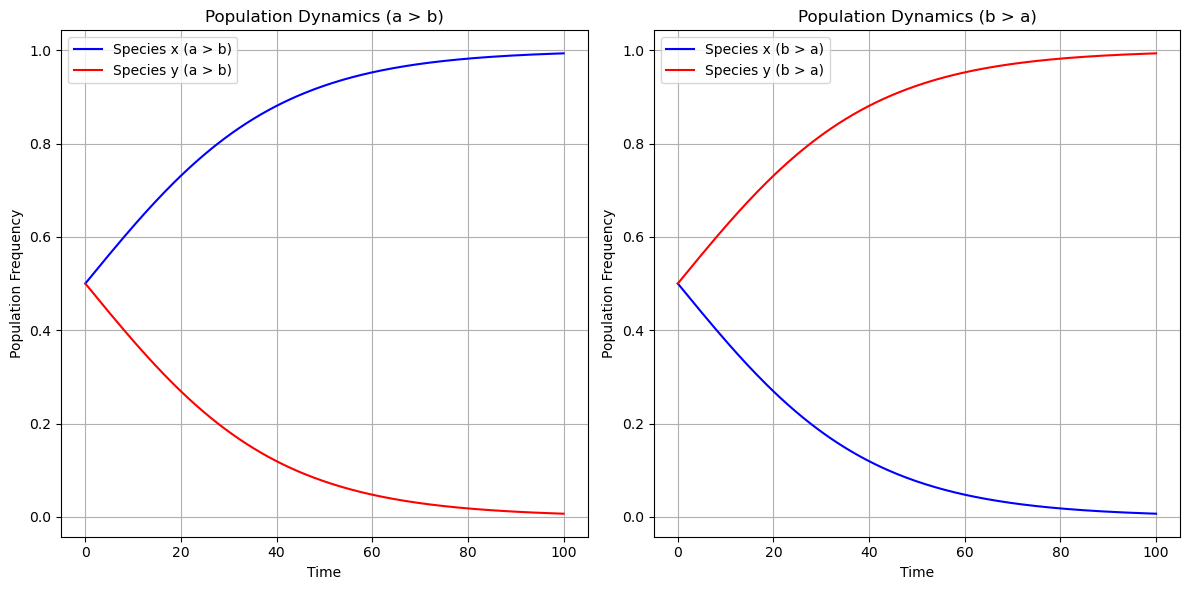

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. تعریف مدل
def model(x, t, a, b):
    # چون جمعیت ثابت است و جمع احتمالات باید 1 باشد: y = 1 - x
    y = 1 - x
    
    # محاسبه میانگین برازش (phi)
    # این متغیر نشان‌دهنده فشار کلی محیط یا میانگین کارایی جامعه است
    phi = a * x + b * y
    
    # معادله دیفرانسیل تغییر سهم x (معادله رپلیکیتور)
    # اگر برازش x (یعنی a) از میانگین (phi) بیشتر باشد، جمعیت رشد می‌کند
    dxdt = x * (a - phi)
    return dxdt

# 2. پارامترها
# حالت اول: a > b (گونه x قوی‌تر است و باید برنده شود)
a1 = 0.1
b1 = 0.05

# حالت دوم: b > a (گونه y قوی‌تر است و باید برنده شود)
a2 = 0.05
b2 = 0.1

# شرایط اولیه (شروع مساوی با سهم ۵۰-۵۰)
x0 = 0.5 

# زمان شبیه‌سازی
t = np.linspace(0, 100, 200)

# 3. حل معادلات
# حل برای حالت اول
sol1 = odeint(model, x0, t, args=(a1, b1))
y_sol1 = 1 - sol1  # چون جمع ۱ است، y را دستی حساب می‌کنیم

# حل برای حالت دوم
sol2 = odeint(model, x0, t, args=(a2, b2))
y_sol2 = 1 - sol2

# 4. رسم نمودارها
plt.figure(figsize=(12, 6))

# نمودار حالت اول (a > b)
plt.subplot(1, 2, 1)
plt.plot(t, sol1, label="Species x (a > b)", color='b')
plt.plot(t, y_sol1, label="Species y (a > b)", color='r')
plt.title("Population Dynamics (a > b)")
plt.xlabel("Time")
plt.ylabel("Population Frequency")
plt.legend()
plt.grid()

# نمودار حالت دوم (b > a)
plt.subplot(1, 2, 2)
plt.plot(t, sol2, label="Species x (b > a)", color='b')
plt.plot(t, y_sol2, label="Species y (b > a)", color='r')
plt.title("Population Dynamics (b > a)")
plt.xlabel("Time")
plt.ylabel("Population Frequency")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

در بخش‌های قبلی، فرض ما این بود که رابطه رشد جمعیت «خطی» است؛ یعنی اگر جمعیت دو برابر شود، قدرت رشد هم دو برابر می‌شود. اما در طبیعت، روابط همیشه اینقدر ساده نیستند. گاهی اوقات روابط «غیرخطی» هستند.

در این مدل، ما یک پارامتر توان به نام $c$ داریم که قواعد بازی را کاملاً عوض می‌کند:

۱. **حالت اول: بازدهی صعودی ($c > 1$):** این حالت شبیه قانون جنگل یا بازارهای انحصاری است. هرچه یک گونه جمعیت بیشتری داشته باشد، قدرتش به صورت تصاعدی بیشتر می‌شود (انگلیسی‌ها می‌گویند: ثروتمند، ثروتمندتر می‌شود). در این حالت، رقابت بسیار خشن است و گونه‌ای که حتی اندکی قوی‌تر باشد، رقیب را کاملاً حذف می‌کند.

۲. **حالت دوم: بازدهی نزولی ($c < 1$):** این حالت شبیه قانون اشباع است. وقتی جمعیت زیاد می‌شود، کارایی هر فرد کمی پایین می‌آید (مثلاً به خاطر شلوغی و تداخل). این ویژگی باعث می‌شود که گونه قوی‌تر نتواند همه منابع را ببلعد و سرعت رشدش کم شود. این "ترمز طبیعی" فرصتی را برای گونه ضعیف‌تر فراهم می‌کند تا او هم زنده بماند. نتیجه این حالت، «همزیستی» و حفظ تنوع زیستی است.

### Non-linear Growth Model (Coexistence vs. Exclusion)

**1. The Non-linear Equation:**
Instead of linear growth ($\dot{x} \propto x$), we introduce a non-linearity parameter $c$:
$$\dot{x} = a x^c - \phi x$$
$$\dot{y} = b y^c - \phi y$$

**2. The Interaction Term ($\phi$):**
To keep the total population constant ($x+y=1$), the environmental pressure $\phi$ becomes:
$$\phi = a x^c + b y^c$$

**3. Dynamical Regimes:**
* **Exclusion ($c > 1$):** Returns to scale are increasing. The system has unstable internal equilibria. The species with the higher initial advantage or growth rate drives the other to extinction.
* **Coexistence ($c < 1$):** Returns to scale are diminishing. The system has a stable internal equilibrium. Both species survive, settling at a ratio defined by their growth rates:
$$x^* = \frac{1}{1 + (a/b)^{\frac{1}{1-c}}}$$

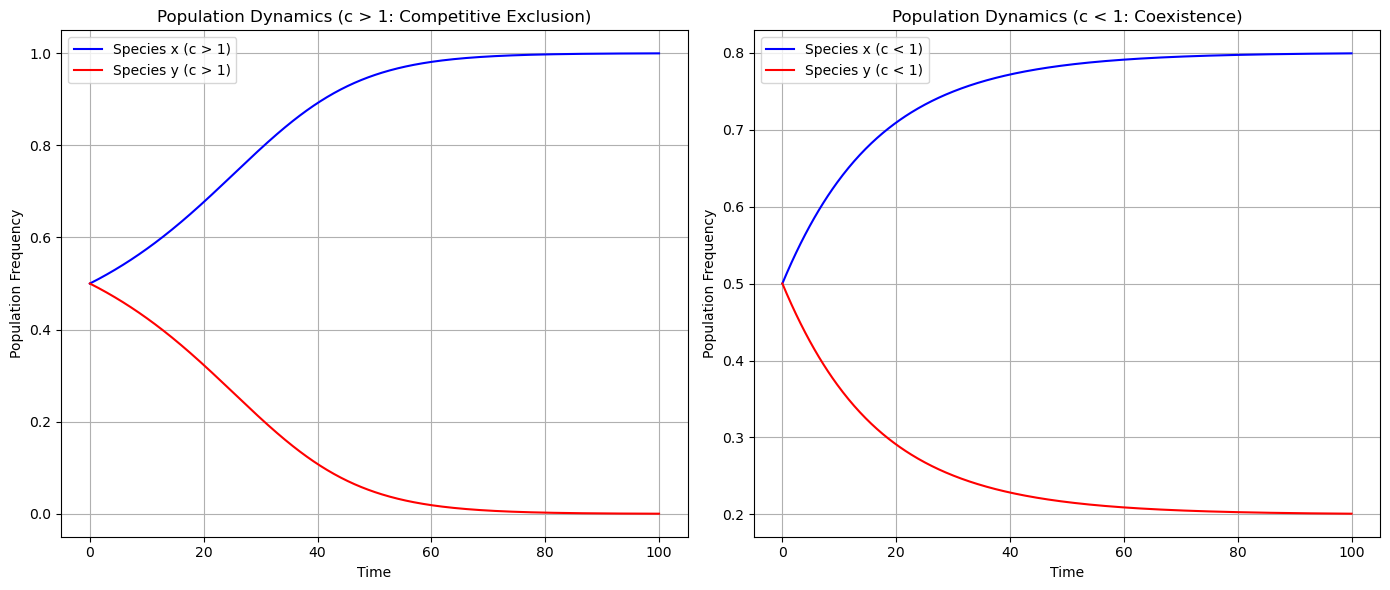

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. تعریف سیستم معادلات
def model(x, t, a, b, c):
    y = 1 - x  # جمعیت کل ثابت است (x + y = 1)
    
    # جمله برهم‌کنش (فی) یا فشار محیط
    # نکته: x**c یعنی x به توان c
    phi = a * (x**c) + b * (y**c)
    
    # نرخ تغییر x
    # رشد ذاتی (ax^c) منهای فشار محیط (phi * x)
    dxdt = a * (x**c) - phi * x
    return dxdt

# 2. پارامترها
# سناریوی اول: c > 1 (بازدهی صعودی -> حذف رقیب)
a1 = 0.1
b1 = 0.05
c1 = 2

# سناریوی دوم: c < 1 (بازدهی نزولی -> همزیستی)
a2 = 0.1
b2 = 0.05
c2 = 0.5

# شرایط اولیه
x0 = 0.5
# زمان شبیه‌سازی
t = np.linspace(0, 100, 500)

# 3. حل معادلات
# حل برای c > 1
sol1 = odeint(model, x0, t, args=(a1, b1, c1))
y_sol1 = 1 - sol1

# حل برای c < 1
sol2 = odeint(model, x0, t, args=(a2, b2, c2))
y_sol2 = 1 - sol2

# 4. رسم نمودار
plt.figure(figsize=(14, 6))

# نمودار c > 1 (جنگ تا انقراض)
plt.subplot(1, 2, 1)
plt.plot(t, sol1, label="Species x (c > 1)", color='b')
plt.plot(t, y_sol1, label="Species y (c > 1)", color='r')
plt.title("Population Dynamics (c > 1: Competitive Exclusion)")
plt.xlabel("Time")
plt.ylabel("Population Frequency")
plt.legend()
plt.grid()

# نمودار c < 1 (همزیستی)
plt.subplot(1, 2, 2)
plt.plot(t, sol2, label="Species x (c < 1)", color='b')
plt.plot(t, y_sol2, label="Species y (c < 1)", color='r')
plt.title("Population Dynamics (c < 1: Coexistence)")
plt.xlabel("Time")
plt.ylabel("Population Frequency")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

در تمام مدل‌های قبلی، سرنوشت نهایی مشخص بود: یا حذف کامل یا پیروزی کامل. اما در دنیای واقعی زیست‌شناسی، پدیده‌ای به نام «جهش» وجود دارد که مثل یک «شیر اطمینان» عمل می‌کند.

جهش یعنی تغییر تصادفی در ژن‌ها. فرض کنید «گونه اول» در حال انقراض است چون ضعیف‌تر است. اما اگر نرخ جهش وجود داشته باشد، ممکن است فرزندان «گونه دوم» بر اثر جهش ژنتیکی، دوباره شبیه «گونه اول» متولد شوند. این یعنی حتی اگر انتخاب طبیعی بخواهد گونه اول را حذف کند، جهش دوباره آن را به سیستم بازمی‌گرداند.

در این شبیه‌سازی ما دو حالت را می‌بینیم:
۱. **جهش یک‌طرفه:** مثل سطل آبی که ته آن سوراخ است. گونه اول مدام به گونه دوم تبدیل می‌شود ولی برعکسش اتفاق نمی‌افتد. نتیجه مشخص است: انقراض تدریجی گونه اول.
۲. **جهش دوطرفه:** در اینجا یک داد و ستد دائمی وجود دارد. سیستم به یک «تعادل» می‌رسد که در آن هیچ‌کس منقرض نمی‌شود. به این حالت «تعادل جهش-انتخاب» می‌گویند. نمودار نشان می‌دهد که جمعیت روی یک عدد خاص ثابت می‌ماند که دقیقاً توسط ریاضیات قابل پیش‌بینی است.

### Mutation-Selection Dynamics

**1. The Mutation Model:**
Individuals reproduce with fidelity, but with a small probability $u$, they mutate into the other species.
* $u_1$: Mutation rate from Species 1 ($x$) to Species 2 ($y$)
* $u_2$: Mutation rate from Species 2 ($y$) to Species 1 ($x$)

**2. The Differential Equations:**
The rate of change is governed by reproduction (minus mutation loss) plus immigration (mutation gain from the other species):
$$\dot{x} = x(1 - u_1) + y u_2 - \phi x$$
$$\dot{y} = y(1 - u_2) + x u_1 - \phi y$$

**3. Mutation-Selection Equilibrium:**
Even without selective advantage, the system settles at a stable equilibrium determined solely by mutation rates:
$$x^* = \frac{u_2}{u_1 + u_2}$$

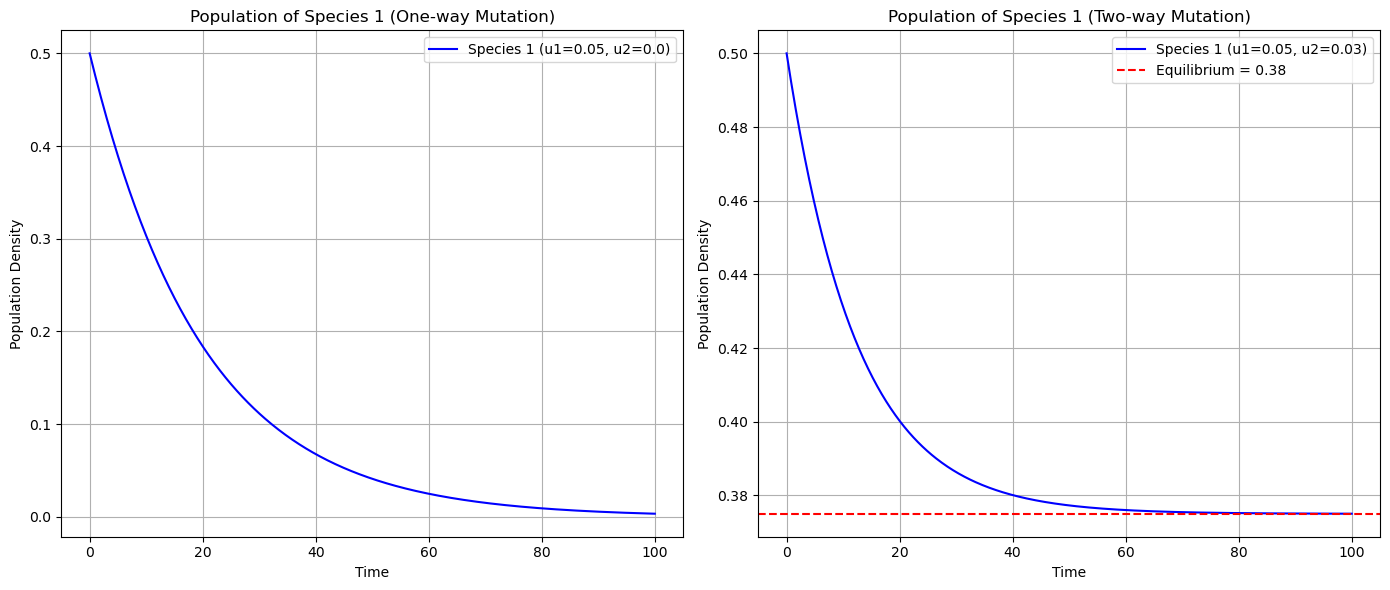

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. تعریف سیستم معادلات با جهش
def model(z, t, u1, u2, phi):
    x, y = z  # باز کردن بردار ورودی
    
    # معادلات دیفرانسیل با در نظر گرفتن نرخ جهش
    # تغییرات x = (رشد x بدون جهش) + (ورودی جهش از y) - (فشار محیط)
    dxdt = x * (1 - u1) + y * u2 - phi * x
    
    # تغییرات y = (رشد y بدون جهش) + (ورودی جهش از x) - (فشار محیط)
    dydt = y * (1 - u2) + x * u1 - phi * y
    
    return [dxdt, dydt]

# تابع محاسبه نقطه تعادل نظری (پیش‌بینی ریاضی)
def equilibrium(u1, u2):
    # فرمول ساده شده برای نقطه تعادل
    return u2 / (u1 + u2)

# 2. پارامترها
phi = 1.0     # ضریب رقابت
x0 = 0.5      # جمعیت اولیه گونه اول
y0 = 1 - x0   # جمعیت اولیه گونه دوم
t = np.linspace(0, 100, 500) # زمان

# سناریو ۱: جهش یک طرفه (فقط گونه اول به دوم تبدیل می‌شود - نابودی اولی)
u1_case1 = 0.05
u2_case1 = 0.0
sol_case1 = odeint(model, [x0, y0], t, args=(u1_case1, u2_case1, phi))

# سناریو ۲: جهش دو طرفه (تعادل پویا)
u1_case2 = 0.05
u2_case2 = 0.03
sol_case2 = odeint(model, [x0, y0], t, args=(u1_case2, u2_case2, phi))

# محاسبه نقطه تعادل نظری برای سناریو ۲
eq_x_case2 = equilibrium(u1_case2, u2_case2)

# 3. رسم نمودار
plt.figure(figsize=(14, 6))

# رسم سناریو ۱
plt.subplot(1, 2, 1)
plt.plot(t, sol_case1[:, 0], label=f"Species 1 (u1={u1_case1}, u2={u2_case1})", color='b')
plt.title("Population of Species 1 (One-way Mutation)")
plt.xlabel("Time")
plt.ylabel("Population Density")
plt.legend()
plt.grid()

# رسم سناریو ۲
plt.subplot(1, 2, 2)
plt.plot(t, sol_case2[:, 0], label=f"Species 1 (u1={u1_case2}, u2={u2_case2})", color='b')
# خط چین قرمز برای نمایش نقطه تعادل نظری
plt.axhline(y=eq_x_case2, color='r', linestyle='--', label=f"Equilibrium = {eq_x_case2:.2f}")

plt.title("Population of Species 1 (Two-way Mutation)")
plt.xlabel("Time")
plt.ylabel("Population Density")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

در بخش‌های پیشین، چارچوب نظری ما بر پایه فرضیات خاصی استوار بود که مهم‌ترین آن‌ها در نظر گرفتن جمعیت‌های بی‌نهایت بزرگ است. در چنین شرایط آرمانی، رفتار سیستم کاملاً قطعی است و نوسانات تصادفی حذف می‌شوند؛ به این معنی که اگر یک گونه شایستگی بیشتری داشته باشد، قطعاً رشد می‌کند و مسیر تکامل یک خط صاف و قابل پیش‌بینی است. اما در سیستم‌های زیستی واقعی، جمعیت‌ها همواره متناهی و محدود هستند.

زمانی که تعداد افراد جمعیت محدود باشد، پدیده‌هایی مانند رانش تصادفی اهمیت حیاتی پیدا می‌کنند. در این حالت، حتی یک گونه با شایستگی کمتر ممکن است صرفاً به دلیل شانس و اقبال در جمعیت تثبیت شود، یا یک گونه برتر بر اثر بدشانسی در همان نسل‌های ابتدایی منقرض گردد. اینجاست که مدل‌های دیفرانسیلی و قطعی دچار محدودیت می‌شوند، زیرا قادر به توصیف نوسانات ذاتی طبیعت نیستند. برای مدل‌سازی دقیق‌تر واقعیت و درک اثر اندازه جمعیت، ما از رویکرد تحلیلی صرف فاصله گرفته و به سمت روش‌های شبیه‌سازی عددی حرکت می‌کنیم. در ادامه، با استفاده از الگوریتم‌های مبتنی بر احتمال، نشان می‌دهیم که چگونه تکامل در گام‌های گسسته و در حضور عنصر شانس و جهش رقم می‌خورد.این بخش قبلا هم در بخش ولگرد و گشت تصادفی تدریس شده و نگاهی گذرا به ان داریم تا کاربردش در دینامیک تکاملی را بیشتر در موردش بحث کنیم

### Stochastic Dynamics: Finite Population with Mutation

Transitioning from continuous differential equations to a discrete stochastic process (Moran Process).
Let $N$ be the total population size, and $i$ be the number of individuals of **Type 1**. The system state evolves via a birth-death process in discrete time steps.

**Mutation Probabilities:**
* $u_1$: Probability that Type 1 mutates to Type 2 during reproduction.
* $u_2$: Probability that Type 2 mutates to Type 1 during reproduction.

The transition probabilities for the number of Type 1 individuals to increase ($T^+$) or decrease ($T^-$) in one time step are given by:

$$
T_{i \to i+1} = \frac{N-i}{N} \times \left[ \frac{f_1 i (1 - u_1) + f_2 (N-i) u_2}{f_1 i + f_2 (N-i)} \right]
$$

$$
T_{i \to i-1} = \frac{i}{N} \times \left[ \frac{f_2 (N-i) (1 - u_2) + f_1 i u_1}{f_1 i + f_2 (N-i)} \right]
$$

**Where:**
* $\frac{N-i}{N}$ is the probability of selecting a Type 2 individual for death.
* $\frac{i}{N}$ is the probability of selecting a Type 1 individual for death.
* The terms in brackets $[ \dots ]$ represent the probability that the newly born individual is of Type 1 (for $T^+$) or Type 2 (for $T^-$), accounting for fitness ($f$) and mutation rates ($u$).

در ادامه مباحث پیشین، اکنون از مدل‌سازی پیوسته و قطعی عبور کرده و وارد دنیای شبیه‌سازی گسسته می‌شویم. هدف از این بخش، بررسی این واقعیت است که وقتی جمعیت محدود باشد، پیش‌بینی‌های قطعی ما تا چه حد با واقعیت همخوانی دارند. در این شبیه‌سازی، ما دیگر با نرخ‌های تغییر لحظه‌ای سروکار نداریم، بلکه تکامل را به صورت یک بازی احتمالات بازسازی می‌کنیم.

در الگوریتم طراحی شده، در هر گام زمانی، یک فرد برای تکثیر انتخاب می‌شود و فرد دیگری به صورت تصادفی حذف می‌گردد تا اندازه جمعیت ثابت بماند. نکته کلیدی اینجاست که در لحظه تکثیر، احتمال وقوع تغییر ماهیت (جهش) نیز در نظر گرفته شده است. با تکرار این فرآیند به دفعات زیاد، مشاهده خواهیم کرد که سیستم به جای ایستادن روی یک نقطه تعادل ثابت، رفتاری پویا و نوسانی از خود نشان می‌دهد که نمایانگر اثرات تصادفی در جمعیت‌های طبیعی است.

### Monte Carlo Simulation: The Moran Process with Mutation

Here, we implement the **Moran Process** to verify the analytical results derived in the previous section. Unlike the differential equations ($\dot{x}$), which assume $N \to \infty$, this simulation tracks the integer number of individuals $i$ in a finite population of size $N$.

**Algorithm Steps:**
1.  **Initialization:** Start with a population of size $N$, with $i_0$ individuals of Type 1.
2.  **Selection (Birth):** In each time step, an individual is chosen to reproduce proportional to its fitness ($f$).
    * If Type 1 is chosen: Offspring is Type 1 with prob $(1-u_1)$ or mutates to Type 2 with prob $u_1$.
    * If Type 2 is chosen: Offspring is Type 2 with prob $(1-u_2)$ or mutates to Type 1 with prob $u_2$.
3.  **Drift (Death):** An individual is chosen uniformly at random to be removed.
4.  **Update:** The population state $i$ updates to $i+1$, $i-1$, or stays $i$.

**Comparison with Theory:**
We will plot the stochastic trajectory against the theoretical equilibrium derived earlier:
$$x^* = \frac{u_2}{u_1 + u_2}$$
This allows us to visualize the **fluctuation** around the stable fixed point due to demographic noise.

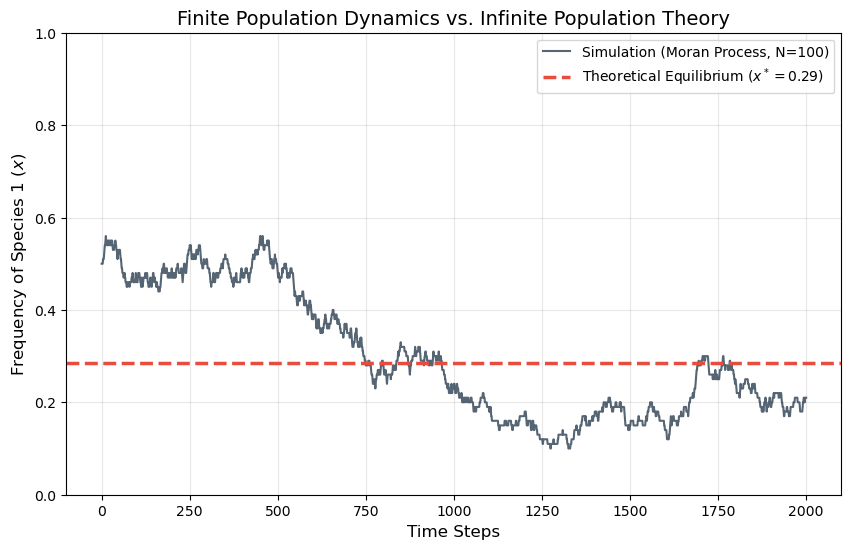

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def moran_process_mutation(N, u1, u2, f1=1.0, f2=1.0, steps=5000):
    """
    شبیه‌سازی فرآیند موران با در نظر گرفتن جهش بین دو گونه.
    
    پارامترها:
    - N: اندازه کل جمعیت (متناهی)
    - u1: نرخ جهش از گونه ۱ به گونه ۲
    - u2: نرخ جهش از گونه ۲ به گونه ۱
    - f1, f2: مقادیر برازش (Fitness)
    - steps: تعداد مراحل شبیه‌سازی
    """
    
    # وضعیت اولیه: شروع با ۵۰ درصد جمعیت از گونه ۱
    i = N // 2
    history = [i / N]  # ذخیره فراوانی گونه ۱ (x)
    
    for _ in range(steps):
        # محاسبه فراوانی فعلی
        x = i / N
        # y = 1 - x
        
        # ۱. انتخاب برای تولید مثل (Birth)
        # احتمال انتخاب گونه ۱ بر اساس برازش (Fitness)
        fit_sum = (f1 * i) + (f2 * (N - i))
        p_select_1 = (f1 * i) / fit_sum
        p_select_2 = (f2 * (N - i)) / fit_sum
        
        # ۲. احتمال تولد گونه ۱ (انتخاب + جهش)
        # گونه ۱ متولد می‌شود اگر: (گونه ۱ انتخاب شود و جهش نکند) یا (گونه ۲ انتخاب شود و به ۱ جهش کند)
        p_birth_1 = p_select_1 * (1 - u1) + p_select_2 * u2
        
        # ۳. فرآیند مرگ (Death)
        # انتخاب تصادفی برای حذف (رانش ژنتیکی)
        # p_death_1 = i / N  (احتمال مرگ گونه ۱)
        # p_death_2 = (N - i) / N
        
        # ۴. تعیین گام بعدی (بروزرسانی تصادفی)
        # محاسبه احتمال افزایش یا کاهش تعداد گونه ۱
        prob_up = p_birth_1 * ((N - i) / N)   # تولد ۱ و مرگ ۲
        prob_down = (1 - p_birth_1) * (i / N) # تولد ۲ و مرگ ۱
        
        r = np.random.random()
        
        if r < prob_up:
            i += 1
        elif r < prob_up + prob_down:
            i -= 1
        # در غیر این صورت i تغییر نمی‌کند
        
        # ذخیره داده‌ها برای رسم نمودار
        history.append(i / N)

    return history

# --- پارامترهای شبیه‌سازی ---
N_population = 100       # اندازه جمعیت محدود
mutation_rate_1 = 0.05   # u1
mutation_rate_2 = 0.02   # u2
sim_steps = 2000

# اجرای شبیه‌سازی
trajectory = moran_process_mutation(N_population, mutation_rate_1, mutation_rate_2, steps=sim_steps)

# محاسبه نقطه تعادل تئوری (برای مقایسه)
# فرمول تعادل: x* = u2 / (u1 + u2)
theoretical_equilibrium = mutation_rate_2 / (mutation_rate_1 + mutation_rate_2)

# --- رسم نمودار ---
plt.figure(figsize=(10, 6))

# رسم مسیر تصادفی (شبیه‌سازی)
plt.plot(trajectory, label=f'Simulation (Moran Process, N={N_population})', color='#2c3e50', alpha=0.8, linewidth=1.5)

# رسم خط تعادل تئوری
plt.axhline(y=theoretical_equilibrium, color='#e74c3c', linestyle='--', linewidth=2.5, 
            label=f'Theoretical Equilibrium ($x^*={theoretical_equilibrium:.2f}$)')

plt.title('Finite Population Dynamics vs. Infinite Population Theory', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Frequency of Species 1 ($x$)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

در گام بعدی از شبیه‌سازی‌های تصادفی، به بررسی یکی از بنیادی‌ترین پرسش‌های تکاملی می‌پردازیم: «آیا برتریِ ذاتی، بقا را تضمین می‌کند؟»
در نگرش کلاسیک و قطعی، پاسخ همواره مثبت است؛ اگر موجودی دارای مزیتی نسبت به سایرین باشد، انتظار داریم که نسل او به مرور زمان جایگزین دیگران شود. اما شبیه‌سازی‌های مبتنی بر احتمال، واقعیت تلخ‌تری را آشکار می‌کنند.

در این سناریو، ما وضعیت «تک‌جهش‌یافته» را مدل‌سازی می‌کنیم: یک فرد با توانایی بقای بالاتر (مثلاً دو برابر رقبا) در میان جمعیتی از افراد معمولی ظاهر می‌شود. شبیه‌سازی نشان می‌دهد که حتی با وجود برتری آشکار، خطر انقراض تصادفی در همان نسل‌های ابتدایی بسیار بالاست. این پدیده نشان می‌دهد که در طبیعت، بسیاری از نوآوری‌های ژنتیکی ارزشمند، نه به دلیل ضعف، بلکه صرفاً به دلیل «بدشانسی» و رانش تصادفی از بین می‌روند. در این بخش، ما صدها بار تاریخ را تکرار می‌کنیم تا ببینیم این "ابرقهرمان" در چند درصد از جهان‌های موازی موفق به فتح کل جمعیت می‌شود.

### Fixation Probability: Selection vs. Random Drift

Here we investigate the fate of a single mutant with relative fitness $r > 1$ introduced into a population of size $N$ consisting of residents with fitness $1$. This is an **Absorbing Markov Chain** where the system eventually hits one of two absorbing states: $i=0$ (Extinction) or $i=N$ (Fixation).

**Transition Probabilities:**
The probability of the mutant population size changing from $i$ to $i \pm 1$ depends on the relative fitness $r$:

$$P_{i \to i+1} = \frac{ri}{ri + (N-i)} \times \frac{N-i}{N}$$
$$P_{i \to i-1} = \frac{N-i}{ri + (N-i)} \times \frac{i}{N}$$

**Theoretical Prediction:**
For a Moran process, the exact probability that a single mutant with relative fitness $r \neq 1$ fixes in the population is given by:

$$\rho_1 = \frac{1 - 1/r}{1 - 1/r^N}$$

**Simulation Strategy:**
We will run $M$ independent simulations (trials). In each trial, we start with $i_0 = 1$. The loop continues until $i$ hits boundary $0$ or $N$. We then calculate the **Empirical Fixation Probability** ($\frac{\text{Successes}}{M}$) and compare it with the theoretical $\rho_1$.

در این کد چند نمونه از مسیرهای تکامل را رسم می‌کنیم (تا ببینید چطور برخی صعود می‌کنند و برخی سقوط).

هزار بار شبیه‌سازی را تکرار می‌کنیم تا "احتمال تثبیت" تجربی را حساب کنیم و با فرمول ریاضی مقایسه کنیم.

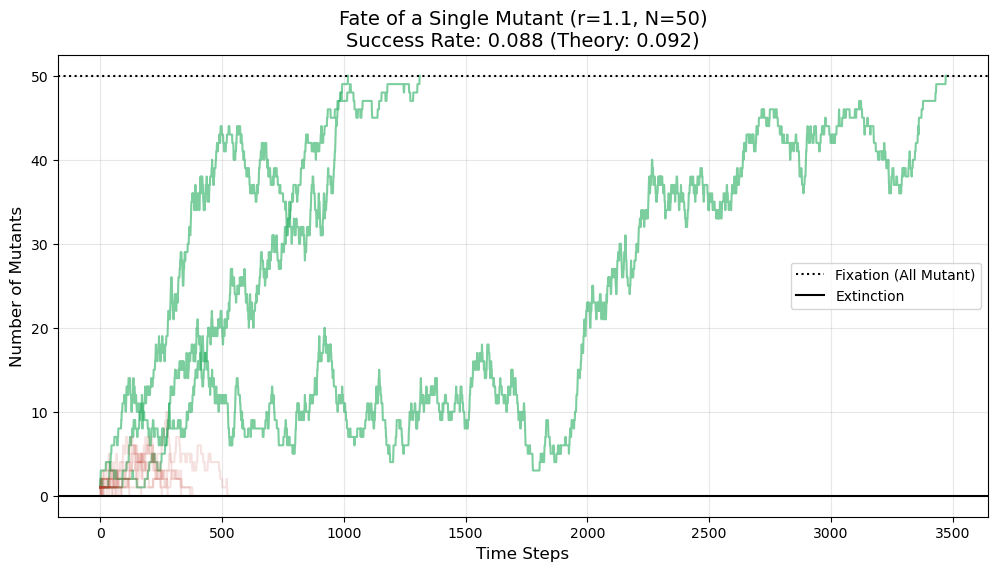

Empirical Fixation Probability: 0.088
Theoretical Fixation Probability: 0.09169015822374545


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# تنظیم بذر تصادفی برای تکرارپذیری نتایج
np.random.seed(101)

def simulate_trajectory(N, r, max_steps=5000):
    """
    اجرای یک دور شبیه‌سازی تا زمانی که جهش‌یافته تثبیت یا منقرض شود.
    
    خروجی:
    - مسیر حرکت (لیست)
    - نتیجه نهایی (True اگر تثبیت شد، False اگر منقرض شد)
    """
    i = 1  # شروع با یک فرد جهش‌یافته
    history = [i]
    
    step = 0
    while 0 < i < N and step < max_steps:
        # احتمال انتخاب جهش‌یافته برای تولید مثل (با برازش r)
        # برازش ساکنین معمولی برابر ۱ فرض می‌شود
        fit_mutant = r * i
        fit_resident = 1 * (N - i)
        total_fit = fit_mutant + fit_resident
        
        p_birth_mutant = fit_mutant / total_fit
        
        # احتمالات گذار
        # افزایش: تولد جهش‌یافته و مرگ ساکن معمولی
        prob_up = p_birth_mutant * ((N - i) / N)
        # کاهش: تولد ساکن معمولی و مرگ جهش‌یافته
        prob_down = (1 - p_birth_mutant) * (i / N)
        
        rand = np.random.random()
        
        if rand < prob_up:
            i += 1
        elif rand < prob_up + prob_down:
            i -= 1
        # در غیر این صورت i ثابت می‌ماند
        
        history.append(i)
        step += 1
        
    return history, (i == N)

# --- پارامترهای آزمایش ---
N_size = 50        # اندازه جمعیت
r_fitness = 1.1    # برازش نسبی جهش‌یافته (۱۰ درصد قوی‌تر)
trials = 500       # تعداد دفعات تکرار آزمایش (جهان‌های موازی)

# ۱. اجرای شبیه‌سازی‌های متعدد
success_count = 0
trajectories = []  # ذخیره مسیرها برای رسم

for _ in range(trials):
    path, result = simulate_trajectory(N_size, r_fitness)
    if result:
        success_count += 1
    # فقط ۳۰ مسیر اول را برای خلوت ماندن نمودار ذخیره می‌کنیم
    if len(trajectories) < 30:
        trajectories.append(path)

# ۲. محاسبات آماری و تئوری
empirical_prob = success_count / trials

# فرمول تئوری احتمال تثبیت
if r_fitness != 1:
    theoretical_prob = (1 - 1/r_fitness) / (1 - 1/r_fitness**N_size)
else:
    theoretical_prob = 1 / N_size

# --- رسم نمودار ---
plt.figure(figsize=(12, 6))

# رسم مسیرهای شبیه‌سازی شده
for path in trajectories:
    if path[-1] == N_size:
        color = '#27ae60'  # سبز برای موفقیت (تثبیت)
        alpha = 0.6
        zorder = 2
    else:
        color = '#c0392b'  # قرمز برای شکست (انقراض)
        alpha = 0.15
        zorder = 1
    plt.plot(path, color=color, alpha=alpha, linewidth=1.5)

plt.axhline(y=N_size, color='black', linestyle=':', label='Fixation (All Mutant)')
plt.axhline(y=0, color='black', linestyle='-', label='Extinction')

plt.title(f'Fate of a Single Mutant (r={r_fitness}, N={N_size})\n'
          f'Success Rate: {empirical_prob:.3f} (Theory: {theoretical_prob:.3f})', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Number of Mutants', fontsize=12)
plt.legend(loc='center right')
plt.grid(True, alpha=0.3)
plt.show()

# چاپ نتیجه در خروجی متنی (بدون نمایش به کاربر نهایی در کد، فقط خروجی کنسول)
print(f"Empirical Fixation Probability: {empirical_prob}")
print(f"Theoretical Fixation Probability: {theoretical_prob}")

تا این مرحله، ما تکامل را شبیه به یک مسابقه دو میدانی می‌دیدیم؛ جایی که هر کس سریع‌تر باشد (برازش ثابت بالاتر)، قطعاً برنده است. اما زندگی اجتماعی پیچیده‌تر از یک مسابقه انفرادی است. در بسیاری از موارد، موفقیت یک استراتژی به این بستگی دارد که «دیگران» چه استراتژی‌ای را انتخاب کرده‌اند. اینجاست که پای «تعاملات اجتماعی» به میان می‌آید.

تصور کنید دو نوع رفتار در جمعیت وجود دارد: رفتار تهاجمی (باز) و رفتار مسالمت‌آمیز (کبوتر). اگر در جمعیتی همه کبوتر باشند، یک فرد باز وارد می‌شود و چون کسی با او نمی‌جنگد، تمام منابع را می‌گیرد و به سرعت تکثیر می‌شود. اما با زیاد شدن بازها، آن‌ها مدام با هم درگیر می‌شوند و آسیب می‌بینند. در این شرایط پر از جنگ، کبوتر بودن (فرار از جنگ) ناگهان استراتژی بهتری می‌شود.

این وابستگی باعث می‌شود جمعیت نه به سمت حذف کامل یکی از دو گروه، بلکه به سمت یک «توازن» حرکت کند. شبیه‌سازی زیر نشان می‌دهد که چگونه جمعیت به جای انقراض یکی از گونه‌ها، حول یک نقطه تعادل نوسان می‌کند؛ جایی که سود جنگیدن و صلح کردن برابر می‌شود. این همان رازی است که باعث حفظ تنوع رفتاری در جوامع زیستی می‌شود.

### Frequency-Dependent Selection: Evolutionary Game Theory

In previous models, fitness $f$ was constant ($f = const$). Now, fitness is a function of the population state ($x$). This introduces **Evolutionary Game Theory**, specifically the **Hawk-Dove Game**.

**Payoff Matrix:**
Consider two strategies, $A$ (Hawk) and $B$ (Dove), with the payoff matrix:
$$
\begin{pmatrix} E(A,A) & E(A,B) \\ E(B,A) & E(B,B) \end{pmatrix} = \begin{pmatrix} a & b \\ c & d \end{pmatrix}
$$
* **Hawk-Dove Conditions:** $a < c$ (It's better to be a Dove if opponent is Hawk) and $b > d$ (It's better to be Hawk if opponent is Dove).

**Frequency-Dependent Fitness:**
If $i$ individuals play $A$ and $N-i$ play $B$, the average fitness of each type is:
$$f_A(i) = \frac{a(i-1) + b(N-i)}{N-1}$$
$$f_B(i) = \frac{c(i) + d(N-i-1)}{N-1}$$

*(Note: We calculate interactions with $N-1$ others).*

**Dynamics:**
The Moran process probabilities now change at every time step as $f_A$ and $f_B$ fluctuate.
The system tends towards the **Evolutionary Stable Strategy (ESS)**, predicted by:
$$x^* = \frac{b - d}{(b - d) + (c - a)}$$
Unlike constant selection, the population is held in a dynamic equilibrium around $x^*$.

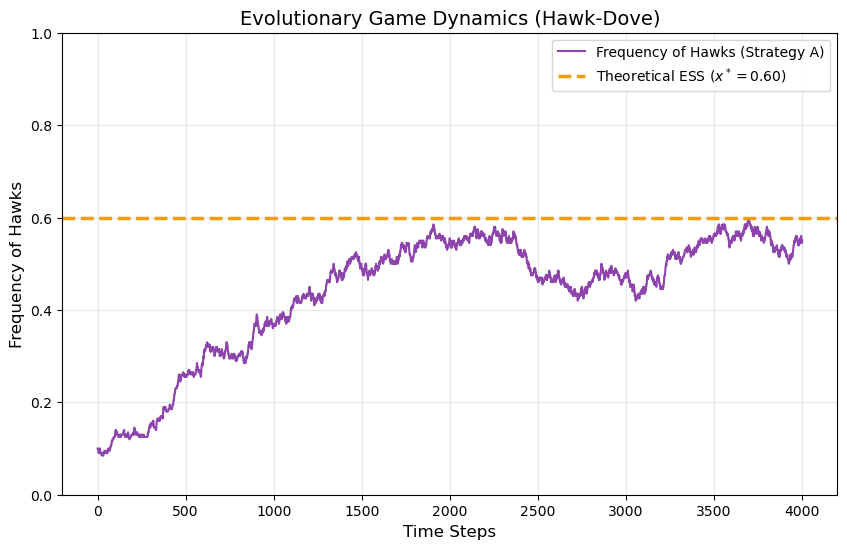

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# تنظیم بذر تصادفی
np.random.seed(42)

def moran_process_game_theory(N, payoff_matrix, steps=3000, mutation_rate=0.01):
    """
    شبیه‌سازی فرآیند موران با انتخاب وابسته به فراوانی (نظریه بازی‌ها).
    """
    # استخراج مقادیر ماتریس پاداش
    # [[a, b], 
    #  [c, d]]
    a, b = payoff_matrix[0][0], payoff_matrix[0][1]
    c, d = payoff_matrix[1][0], payoff_matrix[1][1]
    
    # شروع با تعداد کم از گونه A (مثلاً ۱۰ درصد)
    i = int(N * 0.1)
    history = [i / N]
    
    for _ in range(steps):
        # اگر جمعیت به ۰ یا N برسد و جهش نباشد، بازی تمام است (Absorbing State)
        # اما اینجا برای نمایش پویایی، جهش کوچک را لحاظ می‌کنیم یا شرط توقف نمی‌گذاریم
        if i == 0 or i == N:
            # مکانیزم بازگشت با جهش (برای جلوگیری از قفل شدن نمودار در صفر و صد)
            if np.random.random() < mutation_rate:
                i = 1 if i == 0 else N - 1
            else:
                history.append(i/N)
                continue

        # 1. محاسبه برازش (Fitness) بر اساس تعداد فعلی
        # تعداد رقبا برای هر فرد: N-1
        # برازش گونه A: میانگین پاداش در مقابل Aها و Bها
        # توجه: برای جلوگیری از برازش منفی در شبیه‌سازی احتمالات، یک مقدار پایه (w0) اضافه می‌کنیم
        w0 = 10  # Baseline fitness
        
        f_A = w0 + (a * (i - 1) + b * (N - i)) / (N - 1)
        f_B = w0 + (c * i + d * (N - i - 1)) / (N - 1)
        
        # 2. محاسبه برازش کل جمعیت
        total_fitness = (i * f_A) + ((N - i) * f_B)
        
        # 3. انتخاب برای تولید مثل (Selection)
        p_birth_A = (i * f_A) / total_fitness
        
        # اعمال جهش در پروسه تولد
        # احتمال اینکه بچه واقعاً A شود:
        # (A انتخاب شود و جهش نکند) یا (B انتخاب شود و جهش کند)
        u = mutation_rate
        p_real_birth_A = p_birth_A * (1 - u) + (1 - p_birth_A) * u
        
        # 4. انتخاب برای مرگ (Death) - کاملاً تصادفی
        p_death_A = i / N
        
        # 5. بروزرسانی جمعیت
        prob_up = p_real_birth_A * (1 - p_death_A)   # تولد A و مرگ B
        prob_down = (1 - p_real_birth_A) * p_death_A # تولد B و مرگ A
        
        r = np.random.random()
        
        if r < prob_up:
            i += 1
        elif r < prob_up + prob_down:
            i -= 1
            
        history.append(i / N)
        
    return history

# --- پارامترهای بازی (Hawk-Dove) ---
N_pop = 200
# ماتریس پاداش:
# A (Hawk): [جنگ با باز (منفی), جنگ با کبوتر (سود زیاد)]
# B (Dove): [فرار از باز (صفر), صلح با کبوتر (سود متوسط)]
# شرط تعادل داخلی: a < c و b > d
# مثال: a=-2, b=6, c=0, d=3
# برای سادگی در کد (و جلوگیری از منفی شدن بدون baseline)، مقادیر را مثبت شیفت می‌دهیم:
# a=2 (کمتر), b=10 (زیاد) | c=4 (متوسط به بالا), d=7 (متوسط)
# مقایسه: a(2) < c(4) --> کبوتر بهتر است اگر طرف مقابل باز باشد
# مقایسه: b(10) > d(7) --> باز بهتر است اگر طرف مقابل کبوتر باشد
payoff = [[2, 10], 
          [4, 7]]

# نقطه تعادل تئوری (ESS)
# x* = (b - d) / ((b - d) + (c - a))
# x* = (10 - 7) / ((10 - 7) + (4 - 2)) = 3 / (3 + 2) = 3/5 = 0.6
theo_eq = (payoff[0][1] - payoff[1][1]) / ((payoff[0][1] - payoff[1][1]) + (payoff[1][0] - payoff[0][0]))

# اجرای شبیه‌سازی
traj = moran_process_game_theory(N_pop, payoff, steps=4000, mutation_rate=0.01)

# --- رسم نمودار ---
plt.figure(figsize=(10, 6))
plt.plot(traj, label='Frequency of Hawks (Strategy A)', color='#8e44ad')
plt.axhline(y=theo_eq, color='#f39c12', linestyle='--', linewidth=2.5, label=f'Theoretical ESS ($x^*={theo_eq:.2f}$)')

plt.title('Evolutionary Game Dynamics (Hawk-Dove)', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Frequency of Hawks', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

### جمع‌بندی جامع: از اصول بنیادین تا مرزهای دانش در دینامیک تکاملی

**۱. مقدمه و جایگاه علمی**
دینامیک تکاملی، زبان ریاضیِ حیات است. این شاخه از علم که از تلاقی ریاضیات کاربردی، زیست‌شناسی نظری و فیزیک آماری متولد شده، تلاش می‌کند تا فرایندهای پیچیده‌ی تغییر در جمعیت‌ها را در قالب قوانین دقیق مدون کند. آنچه در این پروژه بررسی شد، تنها مشتی از خروار بود؛ سفری از قطعیتِ معادلات دیفرانسیل به دنیای پرنوسانِ فرایندهای تصادفی.

**۲. مرور تاریخی و تحول پارادایم‌ها**
این علم ریشه در کارهای پیشگامان "سنتز مدرن" در اوایل قرن بیستم دارد؛ جایی که دانشمندانی مانند فیشر و رایت سعی کردند انتخاب طبیعی داروین را با ژنتیک مندلی آشتی دهند. اما جهش بزرگ زمانی رخ داد که نظریه بازی‌ها (توسط جان فون نویمان) و معادلات رپلیکیتور (توسط جان مینارد اسمیت) وارد میدان شدند. ما در این شبیه‌سازی‌ها، عملاً مسیر تاریخی این علم را بازسازی کردیم:
* **گام اول (مدل‌های قطعی):** ابتدا با استفاده از معادلات دیفرانسیل، تکامل را در جمعیت‌های بی‌نهایت بزرگ مدل‌سازی کردیم. این دیدگاه، اگرچه برای پیش‌بینی‌های کلی مفید است، اما "مکانیک نیوتنیِ تکامل" محسوب می‌شود و نویزهای سیستم را نادیده می‌گیرد.
* **گام دوم (مدل‌های استوکستیک):** با ورود به شبیه‌سازی مونت کارلو (فرآیند موران)، نشان دادیم که در جمعیت‌های محدود، "شانس" (رانش ژنتیکی) می‌تواند قدرتمندتر از "انتخاب" عمل کند. این همان جایی است که نظریه خنثیِ تکامل مولکولی (کیمورا) خود را نشان می‌دهد.

**۳. تحلیل یافته‌های پروژه**
در طول این تحقیق محاسباتی، سه اصل کلیدی نمایان شد:
* **نقش حیاتی اندازه جمعیت:** دیدیم که اندازه جمعیت ($N$) صرفاً یک عدد نیست، بلکه پارامتری است که تعیین می‌کند سیستم قطعی رفتار کند یا تصادفی. در جمعیت‌های کوچک، بقا لزوماً از آنِ شایسته‌ترین‌ها نیست، بلکه گاهی از آنِ خوش‌شانس‌ترین‌هاست.
* **تراژدی انقراض جهش‌یافته‌ها:** شبیه‌سازی‌ها نشان داد که حتی جهش‌های سودمند نیز با احتمال بالایی در ابتدای پیدایش حذف می‌شوند. این یافته توضیح می‌دهد که چرا تکامل فرآیندی زمان‌بر است؛ زیرا طبیعت بارها باید تاس بریزد تا یک ویژگی خوب تثبیت شود.
* **پیچیدگی رفتارهای اجتماعی:** با معرفی نظریه بازی‌ها، نشان دادیم که موفقیت یک استراتژی به بافت جامعه وابسته است. این مفهوم (انتخاب وابسته به فراوانی) کلید درک تنوع زیستی و رفتارهای پیچیده مانند همکاری و نوع‌دوستی است.

**۴. کاربردهای فرازیستی**
اصولی که در اینجا پیاده‌سازی کردیم، امروزه فراتر از زیست‌شناسی کاربرد دارند:
* **سرطان‌شناسی:** تومورهای سرطانی به عنوان جمعیت‌هایی از سلول‌های جهش‌یافته که برای منابع می‌جنگند، دقیقاً با همین معادلات (رپلیکیتور و موران) مدل‌سازی می‌شوند.
* **اقتصاد و علوم اجتماعی:** رقابت شرکت‌ها در بازار یا انتشار شایعات در شبکه‌های اجتماعی، از دینامیک مشابهی پیروی می‌کند.
* **تکامل زبان:** چگونگی تغییر کلمات و ساختارهای زبانی در طول زمان نیز نوعی از دینامیک تکاملی فرهنگی است.

**نتیجه‌گیری نهایی**
نهایتاً، این پروژه نشان داد که برای درک عمیق طبیعت، نمی‌توان تنها به یک ابزار بسنده کرد. ما نیازمند ترکیبی از "ریاضیات پیوسته" برای درک روندهای کلان و "شبیه‌سازی‌های گسسته" برای درک نوسانات و عدم قطعیت‌ها هستیم. تکامل، رقص ظریفی میان ضرورت (انتخاب) و تصادف (رانش) است و ابزارهای محاسباتی مدرن به ما اجازه می‌دهند تا نت‌های این موسیقی پیچیده را دیکد کنیم.

### Comprehensive Technical Overview: The Evolutionary Dynamics Framework

This notebook has traversed the theoretical landscape from deterministic mean-field approximations to stochastic definitions of evolution in finite populations. Below is a structured summary of the core concepts, historical context, and mathematical identities explored.

#### I. Historical Context & Foundations
* **The Modern Synthesis (1930s-40s):** Integration of Mendelian genetics with Darwinian selection (Fisher, Wright, Haldane).
* **Neutral Theory (1960s):** Motoo Kimura introduced the importance of Genetic Drift, highlighting that many changes are stochastic rather than adaptive.
* **Evolutionary Game Theory (1970s):** John Maynard Smith and George Price adapted Game Theory (Nash) to biology, introducing the concept of ESS (Evolutionarily Stable Strategy).

#### II. Mathematical Formalism
The project utilized two distinct mathematical regimes to describe population changes:

**1. Deterministic Regime (Infinite Population Limit, $N \to \infty$)**
Used for analyzing the average behavior of large systems.
* **Replicator Equation:** The fundamental differential equation describing selection.
    $$\dot{x}_i = x_i (f_i(\mathbf{x}) - \bar{f}(\mathbf{x}))$$
    *Where $f_i$ is the fitness of type $i$ and $\bar{f}$ is the average population fitness.*
* **Replicator-Mutator Equation:** Adds a mutation matrix $Q_{ji}$ to the selection dynamics.
    $$\dot{x}_i = \sum_{j} x_j f_j Q_{ji} - x_i \bar{f}$$

**2. Stochastic Regime (Finite Population, $N < \infty$)**
Used for analyzing fixation probabilities and extinction times.
* **The Moran Process:** A birth-death process where one individual reproduces and one dies in each time step.
* **Genetic Drift:** The random fluctuation of allele frequencies due to sampling error in finite populations. The magnitude of drift is inversely proportional to population size ($\propto 1/N$).
* **Fixation Probability ($\rho$):** The probability that a single mutant with relative fitness $r$ takes over the population.
    $$\rho = \frac{1 - 1/r}{1 - 1/r^N}$$
    *(For neutral drift where $r=1$, $\rho = 1/N$)*.

#### III. Key Applications
The frameworks implemented here are applicable to diverse complex systems:
* **Somatic Evolution of Cancer:** Modeling tumor progression and resistance to therapy.
* **Viral Dynamics:** Understanding the escape of viruses (like HIV) from the immune system.
* **Social Dynamics:** Evolution of cooperation (Prisoner's Dilemma) and social norms.